# Лабораторная работа №1, задание 2

**Условие.** В первом задании мы видели, что выборочное среднее нормально оценивает матожидание. Но на конкретной выборке оно может плохо оценивать «центр» данных (например, среднюю зарплату), и одна из причин этого выбросы. Здесь рассматривается простая модель с выбросами: выборка из распределения

$$F(x)=(1-\varepsilon)F_{N(\mu,\sigma^2)}(x)+\varepsilon F_{N(\mu,\tau^2)}(x),\qquad \tau^2\gg\sigma^2,$$

где второе слагаемое и есть выбросы. Нужно:

1. найти дисперсию выборочного среднего и асимптотическую дисперсию выборочной медианы;
2. при фиксированных $n$, $\sigma^2$, $\tau^2$ построить графики $n\operatorname{Var}(\overline X)$ и $n\operatorname{Var}(\operatorname{Med}X)$ в зависимости от доли выбросов $\varepsilon$;
3. провести эксперимент как в первом задании: сгенерировать много выборок, у каждой посчитать среднее и медиану, посчитать описательные статистики и нарисовать результаты.

## Что тут вообще происходит

Пример на пальцах. В отделе 20 человек: 19 получают около 100 тысяч, а начальник 2 миллиона. Среднее по отделу выйдет примерно 195 тысяч, хотя так не получает почти никто. Медиана (значение посередине, если всех упорядочить по зарплате) останется около 100 тысяч. Один человек утащил среднее почти в два раза, а медиана его практически не заметила. Вот это и проверяем, только аккуратно.

**Как устроена модель.** Каждое число в выборке получается так: подбрасываем кривую монетку.
- С вероятностью $1-\varepsilon$ берём «нормальное» наблюдение из $N(\mu,\sigma^2)$, у нас это $N(0,1)$.
- С вероятностью $\varepsilon$ берём «выброс» из $N(\mu,\tau^2)$, у нас это $N(0,100)$. Центр тот же, но разброс в 10 раз больше по стандартному отклонению, то есть числа могут улететь очень далеко.

$\varepsilon$ это просто доля выбросов: $\varepsilon=0{,}05$ значит, что примерно 5% выборки мусор.

Выбросы летят в обе стороны одинаково (центр у обоих кусков $\mu$), поэтому и среднее, и медиана **в среднем** попадают в $\mu$. Разница между ними в том, насколько сильно они скачут от одной выборки к другой. Это и меряет дисперсия оценки: чем она меньше, тем точнее оценка.

## Теория

### Дисперсия среднего

Одно наблюдение $X$ с вероятностью $1-\varepsilon$ имеет разброс $\sigma^2$, а с вероятностью $\varepsilon$ имеет разброс $\tau^2$. Так как среднее у обоих кусков одинаковое ($\mu$), разброс всей смеси просто усредняется с этими весами:

$$\operatorname{Var}(X)=\mathbb E(X-\mu)^2=(1-\varepsilon)\sigma^2+\varepsilon\tau^2.$$

Наблюдения независимы, поэтому у среднего из $n$ штук дисперсия в $n$ раз меньше (это было в первом задании):

$$\operatorname{Var}(\overline X)=\frac{(1-\varepsilon)\sigma^2+\varepsilon\tau^2}{n},\qquad n\operatorname{Var}(\overline X)=(1-\varepsilon)\sigma^2+\varepsilon\tau^2.$$

Эта формула точная, никаких приближений. Видно главное: $\tau^2$ входит с множителем $\varepsilon$. У нас $\tau^2=100$, так что даже 5% выбросов добавляют к дисперсии $0{,}05\cdot100=5$, и она вырастает с 1 почти до 6.

### Дисперсия медианы

Для медианы точной простой формулы нет, но есть известный результат для больших $n$: если $m$ это медиана распределения, а $f$ его плотность, то

$$\operatorname{Var}(\operatorname{Med}X)\approx\frac{1}{4n\,f(m)^2}.$$

Смысл такой: медиане важно только, **сколько точек лежит рядом с центром**. Чем плотнее данные около середины (больше $f(m)$), тем точнее медиана. А как далеко улетел выброс, ей всё равно: на 10 он улетел или на 1000, важно только, с какой он стороны от центра. Поэтому медиана и устойчива к выбросам.

У нас смесь симметрична относительно $\mu$, значит $m=\mu$. Плотность нормального закона в его центре равна $\frac{1}{\sigma\sqrt{2\pi}}$, поэтому плотность смеси в точке $\mu$:

$$f(\mu)=(1-\varepsilon)\frac{1}{\sigma\sqrt{2\pi}}+\varepsilon\frac{1}{\tau\sqrt{2\pi}}=\frac{1}{\sqrt{2\pi}}\left(\frac{1-\varepsilon}{\sigma}+\frac{\varepsilon}{\tau}\right).$$

Подставляем, $\frac{2\pi}{4}=\frac{\pi}{2}$:

$$n\operatorname{Var}(\operatorname{Med}X)\approx\frac{\pi}{2}\cdot\frac{1}{\left(\frac{1-\varepsilon}{\sigma}+\frac{\varepsilon}{\tau}\right)^2}.$$

Проверка здравым смыслом: при $\varepsilon=0$ выходит $\frac{\pi}{2}\sigma^2\approx1{,}57\,\sigma^2$. Это известный факт: на чистых нормальных данных медиана примерно в 1,57 раза хуже среднего. А вот выбросы здесь входят мягко, через $\varepsilon/\tau$, а не через $\varepsilon\tau^2$, как у среднего.

Важно: это формула **для больших $n$**. При конечном $n$ реальная дисперсия медианы может немного отличаться, это проверим в эксперименте.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from generation.normal_mixture import sample_mixture
from utils.mixture import n_var_mean, n_var_median, find_crossings, variance_table
from grafics.mixture_plots import plot_asymptotic_variances, plot_estimator_distributions
from grafics.artifacts import save_figure

MU, SIGMA, TAU = 0.0, 1.0, 10.0
N = 500             # объём одной выборки
REPETITIONS = 8000  # сколько выборок генерируем
rng = np.random.default_rng(2026)


## 1. Графики дисперсий от доли выбросов

Берём $\sigma=1$, $\tau=10$ и рисуем обе формулы при $\varepsilon$ от 0 до 1.

Почему рисуем $n\operatorname{Var}$, а не просто $\operatorname{Var}$: сама дисперсия зависит от $n$ (чем больше выборка, тем она меньше), а после умножения на $n$ остаётся только зависимость от $\varepsilon$. Так график один и тот же для любого $n$, в том числе для нашего $n=500$.

Кто ниже на графике, тот и точнее.

Кривые пересекаются при eps ≈ [0.006 0.97 ]


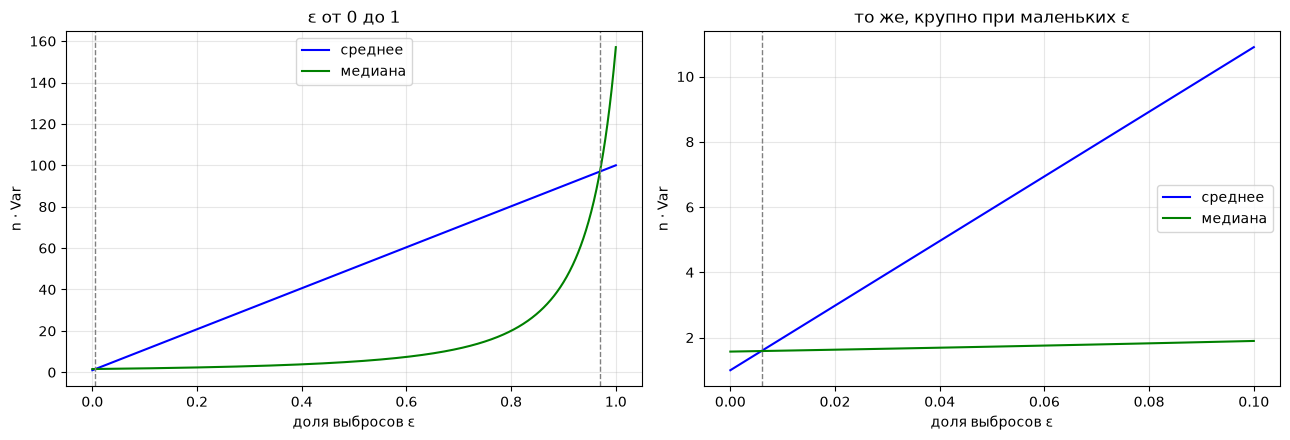

In [2]:
eps_grid = np.linspace(0, 1, 1001)
mean_curve = n_var_mean(eps_grid, SIGMA, TAU)
median_curve = n_var_median(eps_grid, SIGMA, TAU)
crossings = find_crossings(eps_grid, mean_curve, median_curve)
print("Кривые пересекаются при eps ≈", np.round(crossings, 3))

fig = plot_asymptotic_variances(eps_grid, mean_curve, median_curve, crossings)
save_figure(fig, "task_2_asymptotic_variances.png")
plt.show()


**Что видно на графике.**

- При $\varepsilon=0$ выбросов нет, данные чисто нормальные, и среднее лучше (1 против 1,57).
- Но кривая среднего это прямая с наклоном $\tau^2-\sigma^2=99$, она растёт очень быстро. Медиана растёт медленно. Уже где-то с $\varepsilon\approx0{,}006$ (меньше процента выбросов!) медиана становится точнее, см. правый график.
- Дальше разрыв огромный: при $\varepsilon=0{,}05$ у среднего почти 6, у медианы около 1,7.
- Возле $\varepsilon=1$ кривые снова пересекаются. Это логично: если «выбросов» почти 100%, то это уже не выбросы, а просто нормальное распределение с большим разбросом $\tau^2$, и среднее снова выигрывает (100 против $\frac{\pi}{2}\cdot100\approx157$).

То есть нельзя сказать «медиана всегда лучше» или «среднее всегда лучше». Среднее лучше на чистых нормальных данных, медиана лучше, когда есть небольшая доля сильных выбросов. На практике обычно как раз второй случай.

## 2. Эксперимент

Теперь проверяем формулы на сгенерированных данных, как в первом задании. Для каждого $\varepsilon$ из списка:

1. генерируем 8000 выборок по 500 чисел;
2. у каждой выборки считаем среднее и медиану, получаем 8000 средних и 8000 медиан;
3. смотрим, вокруг чего они скачут (должно быть около $\mu=0$) и с каким разбросом. Разброс умножаем на $n$ и сравниваем с формулами.

In [3]:
EPS_VALUES = (0.0, 0.01, 0.05, 0.30, 0.80, 1.0)
results = {}
for eps in EPS_VALUES:
    samples = sample_mixture(rng, (REPETITIONS, N), eps, MU, SIGMA, TAU)
    means = samples.mean(axis=1)
    medians = np.median(samples, axis=1)
    results[eps] = (means, medians)

table = variance_table(results, N, SIGMA, TAU)
table.round(3)


,среднее средних,среднее медиан,nVar среднего (опыт),nVar среднего (формула),nVar медианы (опыт),nVar медианы (формула)
ε,,,,,,
0.00,0.000,0.001,0.987,1.00,1.555,1.571
0.01,0.000,0.001,2.046,1.99,1.609,1.599
0.05,0.001,-0.000,6.001,5.95,1.752,1.722
0.30,-0.000,-0.002,29.980,30.70,2.948,2.948
0.80,0.004,-0.001,79.977,80.20,20.260,20.036
1.00,0.001,-0.000,103.630,100.00,160.763,157.080


**Как читать таблицу.**

- Столбцы «среднее средних» и «среднее медиан» везде около нуля. Значит, обе оценки в среднем попадают в $\mu=0$, систематически никуда не съезжают.
- Для среднего опыт почти идеально совпадает с формулой. Так и должно быть, формула точная.
- Для медианы совпадение тоже хорошее, небольшие расхождения есть, потому что формула верна только при $n\to\infty$, а у нас $n=500$, плюс 8000 повторений это всё-таки не бесконечность.
- И главное: строки 0,01 / 0,05 / 0,30 показывают то же, что и график. При выбросах у медианы разброс в разы меньше.

Ниже ещё обычные описательные статистики для одного случая, $\varepsilon=0{,}05$: по 8000 средним и 8000 медианам.

In [4]:
means, medians = results[0.05]
pd.DataFrame({"среднее": means, "медиана": medians}).describe().round(4)

,среднее,медиана
count,8000.0000,8000.0000
mean,0.0007,-0.0003
std,0.1096,0.0592
min,-0.3917,-0.2053
25%,-0.0727,-0.0399
50%,0.0008,-0.0007
75%,0.0736,0.0398
max,0.4051,0.2466


Тут видно то же самое другими словами: у медиан стандартное отклонение (`std`) и размах от `min` до `max` заметно меньше, чем у средних. Если взять одну случайную выборку, медиана с большей вероятностью окажется близко к настоящему центру.

## 3. Как выглядят распределения оценок

Строим гистограммы 8000 средних и 8000 медиан для $\varepsilon=0$, $0{,}05$ и $0{,}3$. Чтобы масштаб не зависел от $n$, рисуем не саму оценку $\widehat\mu$, а $\sqrt n(\widehat\mu-\mu)$: это то же самое, просто растянутое. Дисперсия у этой величины как раз $n\operatorname{Var}(\widehat\mu)$.

Красная кривая это нормальная плотность с дисперсией из формулы, то есть то, что предсказывает теория. Если гистограмма с ней совпадает, теория работает. Горизонтальная ось у всех картинок одинаковая, чтобы ширину можно было сравнивать на глаз.

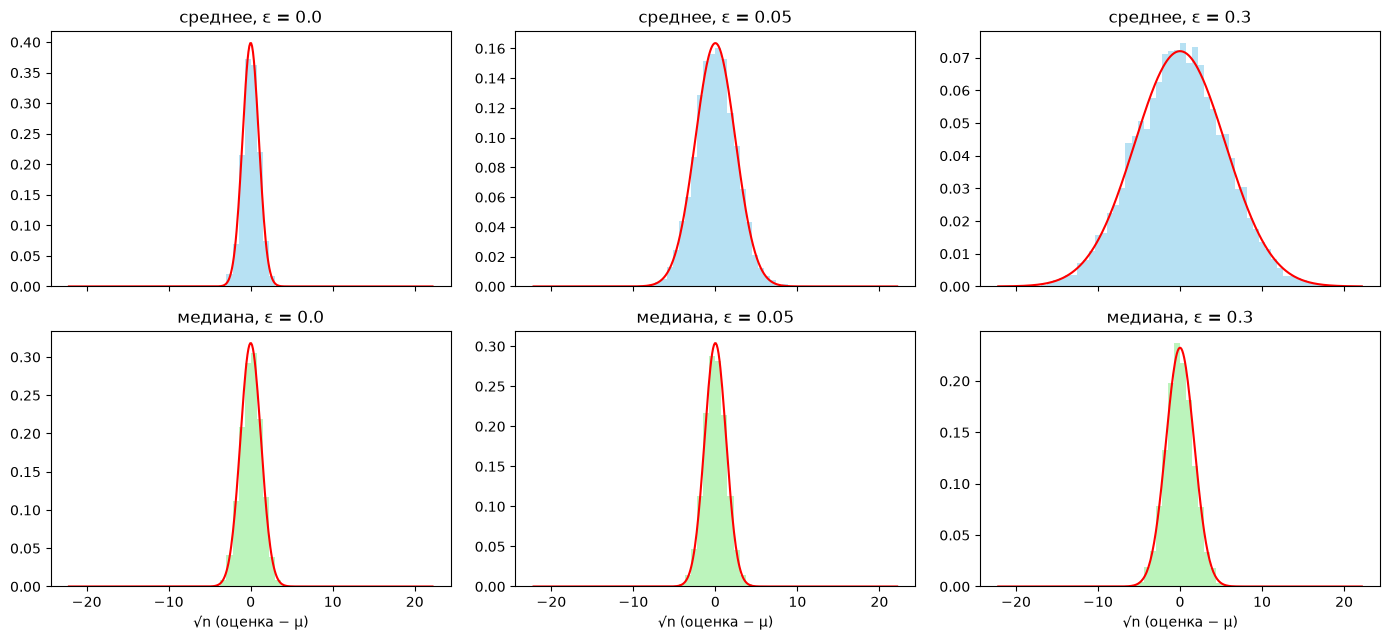

In [5]:
SHOWN_EPS = (0.0, 0.05, 0.30)
normalized_results = {}
theoretical = {}
for eps in SHOWN_EPS:
    means, medians = results[eps]
    normalized_results[eps] = (np.sqrt(N) * (means - MU), np.sqrt(N) * (medians - MU))
    theoretical[eps] = (n_var_mean(eps, SIGMA, TAU), n_var_median(eps, SIGMA, TAU))

fig = plot_estimator_distributions(normalized_results, theoretical)
save_figure(fig, "task_2_estimator_distributions.png")
plt.show()


**Что видно.**

- Гистограммы везде хорошо ложатся на красные кривые, то есть формулы из теории подтверждаются.
- При $\varepsilon=0$ гистограмма среднего чуть уже, чем у медианы: на чистых данных среднее точнее.
- При $\varepsilon=0{,}05$ и особенно $0{,}3$ гистограмма среднего сильно расплывается, а у медианы почти не меняется. Это и есть устойчивость медианы к выбросам.

## Вывод

- Дисперсия среднего: $n\operatorname{Var}(\overline X)=(1-\varepsilon)\sigma^2+\varepsilon\tau^2$. Выбросы входят через $\varepsilon\tau^2$, поэтому даже маленькая доля сильных выбросов сильно портит среднее.
- Асимптотическая дисперсия медианы: $n\operatorname{Var}(\operatorname{Med}X)\approx\frac{\pi}{2}\left(\frac{1-\varepsilon}{\sigma}+\frac{\varepsilon}{\tau}\right)^{-2}$. Медиане важна только плотность данных около центра, поэтому выбросы на неё почти не влияют.
- При $\sigma=1$, $\tau=10$ среднее лучше только при совсем малом $\varepsilon$ (меньше примерно 0,6%) и при $\varepsilon$ близком к 1, когда данные снова просто нормальные. Во всех остальных случаях медиана точнее, например при $\varepsilon=0{,}05$ это примерно 1,7 против 6.
- Эксперимент на 8000 выборках по 500 чисел подтверждает обе формулы: для среднего совпадение почти точное, для медианы с небольшими отклонениями из-за конечного $n$.

Если в данных могут быть выбросы (зарплаты, цены, время ответа сервера и т.п.), медиана как оценка центра надёжнее среднего.